In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("uciml/iris")

print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/datasets/uciml/iris


In [5]:
import pandas as pd
df=pd.read_csv("/kaggle/input/datasets/uciml/iris/Iris.csv")

In [6]:
df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [7]:
df.shape

(150, 6)

In [8]:
df = df.drop('Id', axis=1)

In [9]:
species_mapping = {
    'Iris-setosa': 0, 
    'Iris-versicolor': 1, 
    'Iris-virginica': 2
}
df['Species'] = df['Species'].map(species_mapping)

In [10]:
df.head()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [20]:
df["Species"].unique()

array([0, 1, 2])

In [16]:
X=df.iloc[:,:-1].values
y=df.iloc[:,-1].values

In [19]:
y

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2])

In [21]:
import numpy as np

**TOY DATASET**

In [23]:

mini_data = {
    'PetalLength': [1.4, 1.4, 1.3, 1.5, 1.4,    
                    4.7, 4.5, 4.9, 4.0, 4.6],  
    'Species':     [0, 0, 0, 0, 0,             
                    1, 1, 1, 1, 1]             
}

df_tiny = pd.DataFrame(mini_data)
X_tiny = df_tiny[['PetalLength']].values
y_tiny = df_tiny['Species'].values

print(df_tiny)

   PetalLength  Species
0          1.4        0
1          1.4        0
2          1.3        0
3          1.5        0
4          1.4        0
5          4.7        1
6          4.5        1
7          4.9        1
8          4.0        1
9          4.6        1


In [41]:

def gini(y_labels):
    if len(y_labels) == 0: return 0
    probabilities = np.bincount(y_labels) / len(y_labels)
    return 1 - np.sum(probabilities ** 2)
    
        

In [25]:
sorted_values = np.unique(df_tiny["PetalLength"])

In [26]:
sorted_values

array([1.3, 1.4, 1.5, 4. , 4.5, 4.6, 4.7, 4.9])

In [27]:
thresholds = (sorted_values[:-1] + sorted_values[1:]) / 2

In [28]:
thresholds

array([1.35, 1.45, 2.75, 4.25, 4.55, 4.65, 4.8 ])

In [38]:
left_data=df_tiny["PetalLength"]<=thresholds[0]
y_left_data = np.array(left_data, dtype=int)
print(y_left_data)


[0 0 1 0 0 0 0 0 0 0]


**All this just for the petalLenght**

In [61]:
parent_gini=gini(y_tiny)
best_ig=0
for threshold in thresholds:
    #spliting
    left_data=df_tiny["PetalLength"]<=threshold
    right_data=df_tiny["PetalLength"]>threshold
    y_left_data = y_tiny[left_data]
    y_right_data = y_tiny[right_data]
    gini_left = gini(y_left_data)
    gini_right = gini(y_right_data)
    weight_left = len(y_left_data) / len(y_tiny)
    weight_right = len(y_right_data) / len(y_tiny)
    child_gini = (weight_left * gini_left) + (weight_right * gini_right)
    ig = parent_gini - child_gini
    print(ig)
    if ig > best_ig:
        best_ig = ig
        best_threshold = threshold
    

0.05555555555555558
0.33333333333333337
0.5
0.33333333333333337
0.2142857142857143
0.125
0.05555555555555558


In [62]:
print(f"Best threshold:{best_threshold}")

Best threshold:2.75


In [47]:
import matplotlib.pyplot as plt


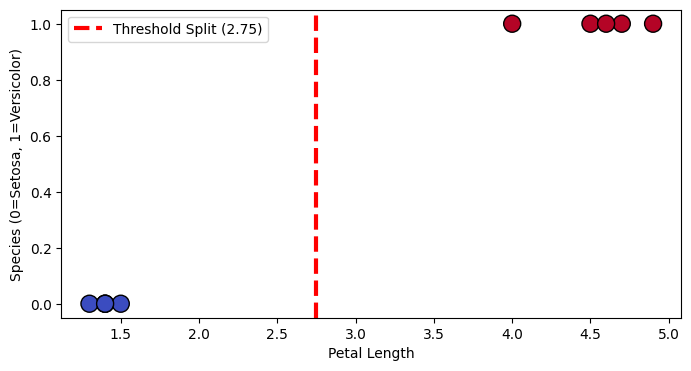

In [63]:
plt.figure(figsize=(8, 4))
plt.scatter(X_tiny, y_tiny, c=y_tiny, cmap='coolwarm', s=150, edgecolor='black')
plt.axvline(x=2.75, color='red', linestyle='--', linewidth=3, label='Threshold Split (2.75)')
plt.xlabel('Petal Length')
plt.ylabel('Species (0=Setosa, 1=Versicolor)')
plt.legend()
plt.show()

**NO MORE FURTEHR SPLITS BECAUS ETHE GINIMPURITY IS ZERO HENCE ITS PURE**